In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, LSTM, GRU, Dense, TimeDistributed, RepeatVector, Multiply, Permute, Flatten
from keras.callbacks import EarlyStopping


## Data Preprocessing

In [2]:
df = pd.read_csv('dataset/merged.csv')
df.drop(columns=['T.Offset', 'H.Offset', 'Target', 'Com_Target', 'Hum_Target', 'Volt_Target', 'Amp_Target'], inplace=True)

# Calculating energy in kWh per minute
df['Energy_kWm'] = (df['Volt'] * df['Amp']) / (1000)

In [3]:
df.describe()

,Room Temparature,Room Humidity (%),Outside Temp,Outside Humid (%),Set Temperature,Volt,Amp,Energy,Energy_kWm
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,28.291302,72.639220,33.301182,74.081145,21.400691,224.068326,4.488756,56.011313,1.004582
std,1.728193,8.829485,2.830021,8.766129,2.012804,3.283313,2.460035,31.426556,0.548528
min,23.600712,43.138298,25.980000,52.000000,18.000000,217.870000,0.036000,1.400000,0.008260
25%,27.614510,68.024093,31.750000,68.522650,19.988235,222.623385,2.409396,26.875000,0.541095
50%,28.920000,77.000000,33.135944,74.375309,21.035294,223.823389,5.064659,56.900000,1.138345
75%,29.495144,78.261908,35.205184,78.950219,23.000000,225.606438,6.647971,87.765000,1.497914
max,30.451864,84.103448,41.846370,94.000000,26.000000,234.655000,7.646000,100.600000,1.782757


In [3]:
# # for diving into three months
# data_points_per_day = 7
# days_per_month = 27
# start_date = datetime(2024, 1, 1, 10)  # Start date: January 1, 2024, at 10 AM

# # Generate timestamps
# timestamps = []
# for i in range(len(df)):
#     # Calculate day and time
#     day_offset = i // data_points_per_day
#     time_offset = i % data_points_per_day
#     timestamp = start_date + timedelta(days=day_offset, hours=time_offset)
#     timestamps.append(timestamp)

# # Add timestamps to the DataFrame
# df["timestamp"] = timestamps


In [4]:
# Interpolating dataset
df['timestamp'] = pd.date_range(start='2023-01-01 00:00:00', periods=df.shape[0], freq='H')

# Interpolate by adding 60 points between each row
expanded_data = []
expanded_timestamps = []

for i in range(len(df) - 1):
    # Current row and next row
    current_row = df.iloc[i]
    next_row = df.iloc[i + 1]
    
    # Generate 60 equally spaced values for each column
    interpolated_rows = {
        col: np.linspace(current_row[col], next_row[col], num=62)[:-1]  # Avoid including the last value
        for col in df.columns if col != 'timestamp'
    }
    
    # Generate timestamps between current and next row
    interpolated_timestamps = pd.date_range(
        start=current_row['timestamp'],
        end=next_row['timestamp'],
        periods=62
    )[:-1]  # Avoid including the last timestamp

    # Combine interpolated values into a DataFrame
    interpolated_df = pd.DataFrame(interpolated_rows)
    interpolated_df['timestamp'] = interpolated_timestamps

    # Append to the expanded data
    expanded_data.append(interpolated_df)

# Combine all expanded data into a single DataFrame
expanded_df = pd.concat(expanded_data, ignore_index=True)

# Add the last row of the original DataFrame to complete the data
expanded_df = pd.concat([expanded_df, df.iloc[[-1]]], ignore_index=True)

# Reset index and check results
expanded_df.reset_index(drop=True, inplace=True)

df = expanded_df

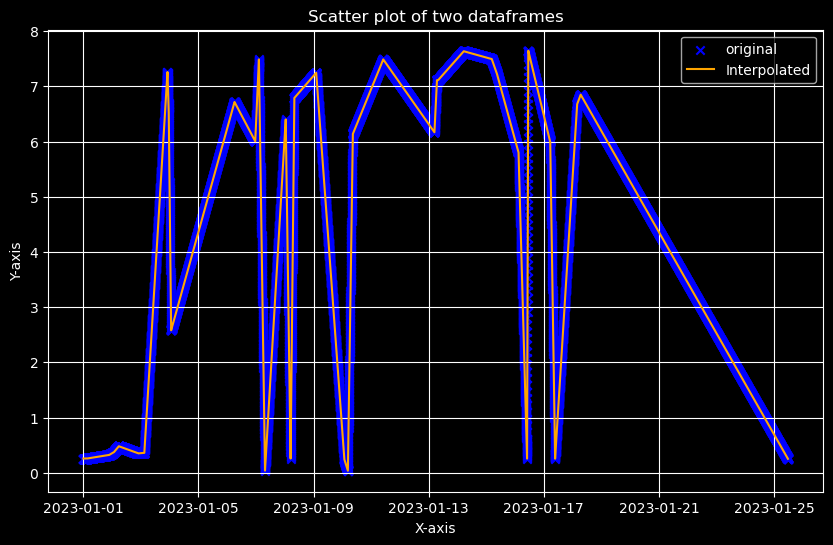

In [5]:
# plotting
plot_df = expanded_df
plot_df['timestamp'] = pd.date_range(start='2023-01-01 00:00:00', periods=plot_df.shape[0], freq='min')

# Plot both dataframes
plt.figure(figsize=(10, 6))

# Plot dataframe with 500 points
plt.scatter(df['timestamp'], df['Amp'], color='blue', label='original', marker='x')

# Plot dataframe with 2000 points
plt.plot(plot_df['timestamp'], plot_df['Amp'], color='orange', label='Interpolated')

# Add labels, legend, and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.title('Scatter plot of two dataframes')
plt.grid(True)

# Show plot
plt.show()


In [6]:
df

,Room Temparature,Room Humidity (%),Outside Temp,Outside Humid (%),Set Temperature,Volt,Amp,Energy,timestamp
0,28.225000,68.333333,31.750000,78.000000,24.000000,225.250000,0.257000,1.400000,2023-01-01 00:00:00
1,28.242402,68.345681,31.750000,78.000000,24.000000,225.250000,0.257000,1.400000,2023-01-01 00:01:00
2,28.259805,68.358029,31.750000,78.000000,24.000000,225.250000,0.257000,1.400000,2023-01-01 00:02:00
3,28.277207,68.370376,31.750000,78.000000,24.000000,225.250000,0.257000,1.400000,2023-01-01 00:03:00
4,28.294609,68.382724,31.750000,78.000000,24.000000,225.250000,0.257000,1.400000,2023-01-01 00:04:00
...,...,...,...,...,...,...,...,...,...
35254,27.942755,60.556620,38.951287,66.171539,18.001543,222.660695,0.254545,100.594176,2023-01-25 11:34:00
35255,27.918444,60.290219,38.950965,66.128654,18.001157,222.660522,0.253909,100.595632,2023-01-25 11:35:00
35256,27.894132,60.023819,38.950643,66.085769,18.000771,222.660348,0.253273,100.597088,2023-01-25 11:36:00
35257,27.869821,59.757418,38.950322,66.042885,18.000386,222.660174,0.252636,100.598544,2023-01-25 11:37:00


In [6]:
X = df.drop(columns=['timestamp'])

y = df['Amp']
predicted_label = "current"

X = X.values
y = y.values

In [7]:
# Normalize data
test_split = 0.6

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_X.fit(X[:int(len(X)*test_split)])
scaler_y.fit(y.reshape(-1, 1)[:int(len(y)*test_split)])

X = scaler_X.transform(X)
y = scaler_y.transform(y.reshape(-1, 1))

In [8]:
# Reshape for LSTM input: [samples, timesteps, features]
sequence_length = 10  # Example: Use the past 24 hours
X_seq, y_seq = [], []

for i in range(len(X) - sequence_length):
    X_seq.append(X[i:i + sequence_length])
    y_seq.append(y[i + sequence_length])

X_seq, y_seq = np.array(X_seq), np.array(y_seq)


In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=(1-test_split), shuffle=False)

## Model

In [10]:
# LSTM model
from model_definition import *
model_name = "gru_attention"
input_shape = (sequence_length, X.shape[1])

model_map = {
    "cnn": build_cnn_model,
    "lstm": build_lstm_model,
    "gru": build_gru_model,
    "bilstm": build_bilstm_model,
    "bigru": build_bigru_model,
    "cnn_lstm": build_cnn_lstm_model,
    "cnn_gru": build_cnn_gru_model,
    "lstm_attention": build_lstm_attention_model,
    "gru_attention": build_gru_attention_model
}

model = model_map[model_name](input_shape) 

In [ ]:
# # Loading model
# checkpoint_path = "checkpoints/"+ model_name + "_" + predicted_label + "_" + str(sequence_length) + ".h5"
# model = tensorflow.keras.models.load_model(checkpoint_path)

In [11]:
# Train the model
early_stopping = EarlyStopping(
    monitor='val_loss',   # Metric to monitor
    patience=10,           # Number of epochs with no improvement to wait
    mode='min',           # 'min' because we want val_loss to decrease
    restore_best_weights=True  # Restore the best weights
)

history = model.fit(X_train, 
                    y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.2, 
                    shuffle=True, 
                    callbacks=[early_stopping]
                    )
# Save the model
checkpoint_path = "checkpoints/"+ model_name + "_" + predicted_label + "_" + str(sequence_length) + ".h5"
model.save(checkpoint_path)


Epoch 1/50
529/529 [==============================] - 12s 16ms/step - loss: 0.0097 - mae: 0.0370 - val_loss: 5.3894e-04 - val_mae: 0.0189
Epoch 2/50
529/529 [==============================] - 9s 16ms/step - loss: 1.5516e-04 - mae: 0.0089 - val_loss: 2.4621e-04 - val_mae: 0.0129
Epoch 3/50
529/529 [==============================] - 11s 21ms/step - loss: 1.0360e-04 - mae: 0.0070 - val_loss: 1.8281e-04 - val_mae: 0.0110
Epoch 4/50
529/529 [==============================] - 13s 25ms/step - loss: 8.3061e-05 - mae: 0.0063 - val_loss: 1.3683e-04 - val_mae: 0.0094
Epoch 5/50
529/529 [==============================] - 14s 27ms/step - loss: 6.3490e-05 - mae: 0.0054 - val_loss: 1.0493e-04 - val_mae: 0.0080
Epoch 6/50
529/529 [==============================] - 11s 20ms/step - loss: 5.7863e-05 - mae: 0.0052 - val_loss: 1.1079e-04 - val_mae: 0.0087
Epoch 7/50
529/529 [==============================] - 7s 14ms/step - loss: 5.4259e-05 - mae: 0.0051 - val_loss: 2.9045e-04 - val_mae: 0.0151
Epoch 8/50
5

In [ ]:
# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")

4/4 [==============================] - 0s 15ms/step - loss: 0.0080 - mae: 0.0630
Test Loss: 0.008035494945943356, Test MAE: 0.06298937648534775


## Plotting

1102/1102 [==============================] - 7s 6ms/step


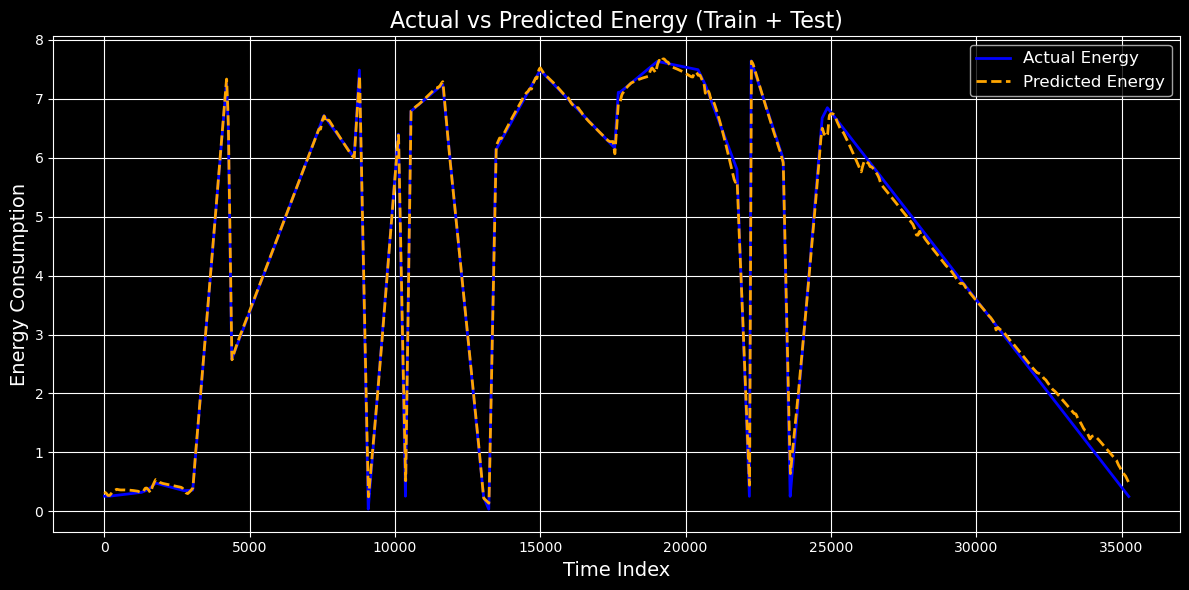

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on both train and test data
predicted = model.predict(X_seq)
predicted = scaler_y.inverse_transform(predicted)
actual = scaler_y.inverse_transform(y_seq)

# Create a time index for plotting (or use actual timestamps if available)
time_index = np.arange(len(actual))

# Plot the combined actual and predicted energy values
plt.figure(figsize=(12, 6))
plt.plot(time_index, actual, label='Actual Energy', color='blue', linewidth=2)
plt.plot(time_index, predicted, label='Predicted Energy', color='orange', linestyle='--', linewidth=2)

# Add labels, title, and legend
plt.title('Actual vs Predicted Energy (Train + Test)', fontsize=16)
plt.xlabel('Time Index', fontsize=14)  # Replace with actual time unit if available
plt.ylabel('Energy Consumption', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [13]:
# prediction on full dataset
predicted = model.predict(X_seq)
predicted = scaler_y.inverse_transform(predicted)
actual = scaler_y.inverse_transform(y_seq)

predicted = predicted.squeeze()
actual = actual.squeeze()

pred_dataset = pd.DataFrame()
pred_dataset['actual'] = actual
pred_dataset['predicted'] = predicted

output_file_path = "output/"+ model_name + "_" + predicted_label + "_" + str(sequence_length) + ".csv"
pred_dataset.to_csv(output_file_path)


1102/1102 [==============================] - 7s 6ms/step


In [14]:
# prediction on test dataset
predicted = model.predict(X_test)
predicted = scaler_y.inverse_transform(predicted)
actual = scaler_y.inverse_transform(y_test)

# Calculate MSE
mse = np.mean((predicted - actual) ** 2)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate NRMSE (using the range of actual values for normalization)
nrmse = rmse / (actual.max() - actual.min())

# Calculate MAE
mae = np.mean(np.abs(predicted - actual))

# Calculate MAPE
mape = np.mean(np.abs((actual - predicted) / actual)) * 100


# Print the results
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"NRMSE: {nrmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

441/441 [==============================] - 3s 7ms/step
MSE: 0.0264
RMSE: 0.1626
NRMSE: 0.0220
MAE: 0.1245
MAPE: 8.7716%


## Thermal Comfort Analysis

In [ ]:
import math

def calculate_pmv_ppd(t_air, t_mean_radiant, rh, air_speed, met, clo):
    """
    Calculate PMV and PPD based on the indoor conditions.
    
    Parameters:
    - t_air (float): Air temperature (°C)
    - t_mean_radiant (float): Mean radiant temperature (°C)
    - rh (float): Relative humidity (%)
    - air_speed (float): Air speed (m/s)
    - met (float): Metabolic rate (met)
    - clo (float): Clothing insulation (clo)
    
    Returns:
    - pmv (float): Predicted Mean Vote
    - ppd (float): Predicted Percentage of Dissatisfied (%)
    """
    # Constants
    pa = rh * 10 * math.exp(16.6536 - 4030.183 / (t_air + 235))
    icl = 0.155 * clo  # Clothing insulation in m²·K/W
    m = met * 58.15  # Metabolic rate in W/m²
    w = 0  # External work (assumed 0 for most indoor conditions)
    mw = m - w  # Internal heat production
    f_cl = 1.05 + 0.1 * clo if clo > 0.5 else 1 + 0.2 * clo  # Clothing area factor

    # Heat transfer coefficients
    h_c = 12.1 * math.sqrt(air_speed)
    t_cl = t_air + (35.5 - t_air) / (3.5 * clo + 0.1)

    for _ in range(2):
        h_c = max(2.38 * abs(35.5 - t_cl)**0.25, h_c)
        t_cl = (t_air + t_mean_radiant) / 2 + (35.5 - t_air) / (3.5 * clo + 0.1)

    # Heat balance
    t_cl_radiant = f_cl * h_c * (t_cl - t_air)
    t_cl_convection = f_cl * 3.96 * (10**-8) * ((t_cl + 273)**4 - (t_mean_radiant + 273)**4)
    t_cl_total = t_cl_radiant + t_cl_convection 
    hl1 = 3.05 * 0.001 * (5733 - (6.99 * mw) - pa)  # Heat loss through respiration
    hl2 = 0.42 * (mw - 58.15)  # Heat loss through sweating
    hl3 = 1.7 * 0.00001 * m * (5867 - pa)  # Latent respiration heat loss
    hl4 = 0.0014 * m * (34 - t_air)  # Dry respiration heat loss
    hl5 = t_cl_total  # Heat transfer through skin

    # Total heat loss
    heat_loss = hl1 + hl2 + hl3 + hl4 + hl5

    # PMV calculation
    pmv = (0.303 * math.exp(-0.036 * met) + 0.028) * heat_loss

    # PPD calculation
    ppd = 100 - 95 * math.exp(-0.03353 * pmv**4 - 0.2179 * pmv**2)

    return pmv, ppd


# Inputs
t_air = 24 # Air temperature in °C
t_mean_radiant = 25  # Mean radiant temperature in °C
rh = 71  # Relative humidity in %
air_speed = 0.1  # Air speed in m/s
met = 1.2  # Metabolic rate in met (e.g., office work)
clo = 0.5  # Clothing insulation in clo (e.g., summer clothing)

pmv, ppd = calculate_pmv_ppd(t_air, t_mean_radiant, rh, air_speed, met, clo)
print(f"PMV: {pmv:.2f}, PPD: {ppd:.2f}%")


PMV: 13.81, PPD: 100.00%


In [ ]:
from pythermalcomfort.models import pmv_ppd
from pythermalcomfort.utilities import v_relative, clo_dynamic
from pythermalcomfort.utilities import met_typical_tasks
from pythermalcomfort.utilities import clo_individual_garments

# input variables
tdb = 25  # dry bulb air temperature, [$^{\circ}$C]
tr = 25  # mean radiant temperature, [$^{\circ}$C]
v = 0.1  # average air speed, [m/s]
rh = 50  # relative humidity, [%]
activity = "Typing"  # participant's activity description
garments = ["Sweatpants", "T-shirt", "Shoes or sandals"]

met = met_typical_tasks[activity]  # activity met, [met]

icl = sum(
    [clo_individual_garments[item] for item in garments]
)  # calculate total clothing insulation

# calculate the relative air velocity
vr = v_relative(v=v, met=met)
# calculate the dynamic clothing insulation
clo = clo_dynamic(clo=icl, met=met)

# calculate PMV in accordance with the ASHRAE 55 2020
results = pmv_ppd(tdb=tdb, tr=tr, vr=vr, rh=rh, met=met, clo=clo, standard="ASHRAE")

# print the results
print(results)

# print PMV value
print(f"pmv={results['pmv']}, ppd={results['ppd']}%")


1.1
{'pmv': -0.52, 'ppd': 10.6}
pmv=-0.52, ppd=10.6%


d:\anaconda\envs\AI\lib\site-packages\pythermalcomfort\models\cooling_effect.py:137: UserWarning: Assuming cooling effect = 0 since it could not be calculated for this set of inputs tdb=25, tr=25, rh=50, vr=0.13, clo=0.38000000000000006, met=1.1
  warnings.warn(
